# CIS 433 Project 2 Smiley Face Manipulation

This notebook uses the instructor pretrained VAE model and computes a smile attribute direction from CelebA labels.  
It extracts images to local Colab storage only and does not create extra folders in Google Drive.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Project paths in Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/CIS433_Hadi Hussain__Project2_Smiley")
ZIP_PATH = PROJECT_DIR / "img_align_celeba.zip"
CSV_PATH = PROJECT_DIR / "list_attr_celeba.csv"
MODEL_PATH = PROJECT_DIR / "vae_celeba_128x128_128.pt"

print("PROJECT_DIR exists:", PROJECT_DIR.exists())
print("ZIP exists:", ZIP_PATH.exists())
print("CSV exists:", CSV_PATH.exists())
print("MODEL exists:", MODEL_PATH.exists())

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV file not found: {CSV_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

PROJECT_DIR exists: True
ZIP exists: True
CSV exists: True
MODEL exists: True


In [7]:
# Extract images to local Colab storage only
LOCAL_DATA_DIR = Path("/content/celeba_project2")
LOCAL_IMG_ROOT = LOCAL_DATA_DIR / "img_align_celeba"

if not LOCAL_IMG_ROOT.exists():
    LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(LOCAL_DATA_DIR)
    print("Images extracted to local Colab storage.")
else:
    print("Images already available in local Colab storage.")

# Some zip files extract as /img_align_celeba/img_align_celeba
nested_candidate = LOCAL_IMG_ROOT / "img_align_celeba"
if nested_candidate.exists():
    LOCAL_IMG_ROOT = nested_candidate

sample_files = sorted([p.name for p in LOCAL_IMG_ROOT.iterdir() if p.suffix.lower() == ".jpg"])[:5]
print("Image root:", LOCAL_IMG_ROOT)
print("Sample files:", sample_files)

if len(sample_files) == 0:
    raise RuntimeError("No JPG images found after extraction.")

Images extracted to local Colab storage.
Image root: /content/celeba_project2/img_align_celeba/img_align_celeba
Sample files: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']


In [8]:
# Load CelebA attribute file
attr_df = pd.read_csv(CSV_PATH)
if "image_id" not in attr_df.columns:
    # fallback for odd parsing
    attr_df = pd.read_csv(CSV_PATH, delim_whitespace=True)
    attr_df = attr_df.reset_index().rename(columns={"index": "image_id"})

# Normalize Smiling labels to {0,1}
if set(pd.unique(attr_df["Smiling"])) == {-1, 1}:
    attr_df["Smiling"] = (attr_df["Smiling"] == 1).astype(int)
else:
    attr_df["Smiling"] = attr_df["Smiling"].astype(int)

print(attr_df[["image_id", "Smiling"]].head())
print("Total rows:", len(attr_df))

     image_id  Smiling
0  000001.jpg        1
1  000002.jpg        1
2  000003.jpg        0
3  000004.jpg        0
4  000005.jpg        0
Total rows: 202599


In [9]:
IMG_H, IMG_W = 128, 128
D_LATENT = 128
N_FILTERS = (128, 128, 128, 128, 128)

class Sampler(nn.Module):
    def forward(self, z_mean, z_logvar):
        epsilon = torch.randn_like(z_mean)
        return z_mean + torch.exp(0.5 * z_logvar) * epsilon

class Encoder(nn.Module):
    def __init__(self, n_filters=N_FILTERS, d_latent=D_LATENT):
        super().__init__()
        self.conv_1 = nn.Conv2d(3, n_filters[0], 3, stride=2, padding=1)
        self.conv_2 = nn.Conv2d(n_filters[0], n_filters[1], 3, stride=2, padding=1)
        self.conv_3 = nn.Conv2d(n_filters[1], n_filters[2], 3, stride=2, padding=1)
        self.conv_4 = nn.Conv2d(n_filters[2], n_filters[3], 3, stride=2, padding=1)
        self.conv_5 = nn.Conv2d(n_filters[3], n_filters[4], 3, stride=2, padding=1)

        self.bn_1 = nn.BatchNorm2d(n_filters[0])
        self.bn_2 = nn.BatchNorm2d(n_filters[1])
        self.bn_3 = nn.BatchNorm2d(n_filters[2])
        self.bn_4 = nn.BatchNorm2d(n_filters[3])
        self.bn_5 = nn.BatchNorm2d(n_filters[4])

        self.leaky_relu = nn.LeakyReLU()
        self.flatten = nn.Flatten()

        final_h = IMG_H // (2 ** len(n_filters))
        final_w = IMG_W // (2 ** len(n_filters))
        flattened_size = int(n_filters[-1] * final_h * final_w)

        self.dense_mean = nn.Linear(flattened_size, d_latent)
        self.dense_logvar = nn.Linear(flattened_size, d_latent)

    def forward(self, inputs):
        x = self.leaky_relu(self.bn_1(self.conv_1(inputs)))
        x = self.leaky_relu(self.bn_2(self.conv_2(x)))
        x = self.leaky_relu(self.bn_3(self.conv_3(x)))
        x = self.leaky_relu(self.bn_4(self.conv_4(x)))
        x = self.leaky_relu(self.bn_5(self.conv_5(x)))
        x = self.flatten(x)
        z_mean = self.dense_mean(x)
        z_logvar = self.dense_logvar(x)
        return z_mean, z_logvar

class Decoder(nn.Module):
    def __init__(self, img_shape=(IMG_H, IMG_W), n_filters=N_FILTERS, d_latent=D_LATENT):
        super().__init__()
        self.shape_before_flattening = (
            n_filters[-1],
            img_shape[0] // (2 ** len(n_filters)),
            img_shape[1] // (2 ** len(n_filters))
        )

        flat_dim = int(np.prod(self.shape_before_flattening))

        self.dense = nn.Linear(d_latent, flat_dim)
        self.bn_dense = nn.BatchNorm1d(flat_dim)

        self.conv_1 = nn.ConvTranspose2d(n_filters[-1], n_filters[-1], 3, stride=2, padding=1, output_padding=1)
        self.conv_2 = nn.ConvTranspose2d(n_filters[-2], n_filters[-2], 3, stride=2, padding=1, output_padding=1)
        self.conv_3 = nn.ConvTranspose2d(n_filters[-3], n_filters[-3], 3, stride=2, padding=1, output_padding=1)
        self.conv_4 = nn.ConvTranspose2d(n_filters[-4], n_filters[-4], 3, stride=2, padding=1, output_padding=1)
        self.conv_5 = nn.ConvTranspose2d(n_filters[-5], n_filters[-5], 3, stride=2, padding=1, output_padding=1)

        self.bn_1 = nn.BatchNorm2d(n_filters[-1])
        self.bn_2 = nn.BatchNorm2d(n_filters[-2])
        self.bn_3 = nn.BatchNorm2d(n_filters[-3])
        self.bn_4 = nn.BatchNorm2d(n_filters[-4])
        self.bn_5 = nn.BatchNorm2d(n_filters[-5])

        self.conv_out = nn.ConvTranspose2d(n_filters[-5], 3, kernel_size=3, stride=1, padding=1)

        self.leaky_relu = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, latent_input):
        x = self.dense(latent_input)
        x = self.bn_dense(x)
        x = self.leaky_relu(x)
        x = x.view(-1, *self.shape_before_flattening)

        x = self.leaky_relu(self.bn_1(self.conv_1(x)))
        x = self.leaky_relu(self.bn_2(self.conv_2(x)))
        x = self.leaky_relu(self.bn_3(self.conv_3(x)))
        x = self.leaky_relu(self.bn_4(self.conv_4(x)))
        x = self.leaky_relu(self.bn_5(self.conv_5(x)))

        return self.sigmoid(self.conv_out(x))

class VAE(nn.Module):
    def __init__(self, img_shape=(IMG_H, IMG_W), n_filters=N_FILTERS, d_latent=D_LATENT):
        super().__init__()
        self.encoder = Encoder(n_filters=n_filters, d_latent=d_latent)
        self.decoder = Decoder(img_shape=img_shape, n_filters=n_filters, d_latent=d_latent)
        self.sampler = Sampler()

    def forward(self, inputs):
        z_mean, z_logvar = self.encoder(inputs)
        z = self.sampler(z_mean, z_logvar)
        reconstruction = self.decoder(z)
        return z_mean, z_logvar, z, reconstruction

## Optional training section
This cell shows the full VAE training pipeline for the CelebA dataset. For the final project workflow, I used the instructor provided pretrained PyTorch model to save time and focus on latent space manipulation, as discussed in class.


In [ ]:
# Optional training cell for Project 2
# This is included to show the full training pipeline.

train_model = VAE().to(device)
optimizer = torch.optim.Adam(train_model.parameters(), lr=1e-4)

# You can keep this small since you are not running it for real training
n_epochs = 5
beta = 1.0

train_history = {
    "total_loss": [],
    "reconstruction_loss": [],
    "kl_loss": []
}

train_model.train()

for epoch in range(1, n_epochs + 1):
    epoch_total = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0
    n_samples = 0

    for images, attributes in dataloader:
        images = images.to(device)
        batch_size = images.size(0)

        optimizer.zero_grad()

        z_mean, z_logvar, z, reconstruction = train_model(images)

        reconstruction_loss = torch.mean((reconstruction - images) ** 2)

        kl_loss = -0.5 * torch.mean(
            1 + z_logvar - z_mean.pow(2) - torch.exp(z_logvar)
        )

        total_loss = reconstruction_loss + beta * kl_loss

        total_loss.backward()
        optimizer.step()

        epoch_total += total_loss.item() * batch_size
        epoch_recon += reconstruction_loss.item() * batch_size
        epoch_kl += kl_loss.item() * batch_size
        n_samples += batch_size

    avg_total = epoch_total / n_samples
    avg_recon = epoch_recon / n_samples
    avg_kl = epoch_kl / n_samples

    train_history["total_loss"].append(avg_total)
    train_history["reconstruction_loss"].append(avg_recon)
    train_history["kl_loss"].append(avg_kl)

    print(
        f"Epoch {epoch}/{n_epochs} | "
        f"Total Loss: {avg_total:.6f} | "
        f"Reconstruction Loss: {avg_recon:.6f} | "
        f"KL Loss: {avg_kl:.6f}"
    )

TRAINED_MODEL_PATH = PROJECT_DIR / "hadi_project2_trained_from_scratch.pt"
torch.save(train_model.state_dict(), TRAINED_MODEL_PATH)
print("Training complete. Model saved to:", TRAINED_MODEL_PATH)

In [10]:
# Load instructor pretrained model
model = VAE().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)

if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state = checkpoint["state_dict"]
elif isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state = checkpoint["model_state_dict"]
else:
    state = checkpoint

model.load_state_dict(state, strict=True)
model.eval()

print("Loaded pretrained checkpoint from:", MODEL_PATH.name)

Loaded pretrained checkpoint from: vae_celeba_128x128_128.pt


In [11]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

class CelebASmilingDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        self.df = df.copy()
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_root / row["image_id"]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        attributes = {"Smiling": int(row["Smiling"])}
        return image, attributes

dataset = CelebASmilingDataset(attr_df, LOCAL_IMG_ROOT, transform=transform)
dataloader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)

print("Dataset size:", len(dataset))

Dataset size: 202599


In [12]:
def load_face_tensor(img_path):
    pil_img = Image.open(img_path).convert("RGB")
    img_tensor = transform(pil_img).unsqueeze(0).to(device)
    return img_tensor, pil_img

def tensor_to_image(tensor_4d):
    return tensor_4d.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

In [13]:
# Compute smile direction using instructor style convergence logic
direction = "Smiling"
convergence_criterion = 0.01

print("POS move : NEG move :")
current_n_POS, current_n_NEG = 0, 0

current_sum_POS = np.zeros(shape=D_LATENT, dtype="float32")
current_mean_POS = np.zeros(shape=D_LATENT, dtype="float32")

current_sum_NEG = np.zeros(shape=D_LATENT, dtype="float32")
current_mean_NEG = np.zeros(shape=D_LATENT, dtype="float32")

attribute_vec = np.zeros(shape=D_LATENT, dtype="float32")

for images, attributes in dataloader:
    with torch.no_grad():
        img_tensor = images.to(device)
        mu, _ = model.encoder(img_tensor)

    for i, z in enumerate(mu):
        if attributes[direction][i] == 1:
            current_sum_POS += z.cpu().numpy()
            current_n_POS += 1
        else:
            current_sum_NEG += z.cpu().numpy()
            current_n_NEG += 1

    new_mean_POS = current_sum_POS / current_n_POS
    new_mean_NEG = current_sum_NEG / current_n_NEG

    delta_POS = np.linalg.norm(new_mean_POS - current_mean_POS)
    delta_NEG = np.linalg.norm(new_mean_NEG - current_mean_NEG)

    current_mean_POS = np.copy(new_mean_POS)
    current_mean_NEG = np.copy(new_mean_NEG)

    attribute_vec = new_mean_POS - new_mean_NEG
    print(str(np.round(delta_POS, 3)) + "    : " + str(np.round(delta_NEG, 3)))

    if delta_POS + delta_NEG < convergence_criterion:
        attribute_vec /= np.linalg.norm(attribute_vec)
        print("Found the vector")
        break

attribute_vec = torch.tensor(attribute_vec, dtype=torch.float32).to(device)
print("Smile vector shape:", attribute_vec.shape)

POS move : NEG move :
9.89    : 7.597
4.484    : 3.514
2.474    : 2.038
1.637    : 1.843
0.924    : 1.507
0.731    : 1.26
0.964    : 0.862
0.654    : 1.008
0.61    : 0.566
0.568    : 0.579
0.455    : 0.605
0.423    : 0.466
0.449    : 0.449
0.453    : 0.407
0.317    : 0.428
0.441    : 0.326
0.307    : 0.345
0.357    : 0.294
0.284    : 0.27
0.232    : 0.349
0.246    : 0.261
0.215    : 0.259
0.3    : 0.265
0.256    : 0.182
0.193    : 0.228
0.174    : 0.215
0.189    : 0.195
0.239    : 0.22
0.227    : 0.168
0.211    : 0.19
0.162    : 0.145
0.22    : 0.195
0.157    : 0.153
0.199    : 0.181
0.176    : 0.163
0.146    : 0.147
0.143    : 0.14
0.203    : 0.127
0.115    : 0.131
0.124    : 0.141
0.11    : 0.144
0.132    : 0.136
0.156    : 0.154
0.104    : 0.114
0.125    : 0.121
0.113    : 0.146
0.106    : 0.145
0.109    : 0.094
0.121    : 0.124
0.121    : 0.096
0.13    : 0.092
0.105    : 0.1
0.105    : 0.095
0.095    : 0.1
0.082    : 0.099
0.112    : 0.104
0.095    : 0.121
0.104    : 0.072
0.102   

Using test image: 193036.jpg


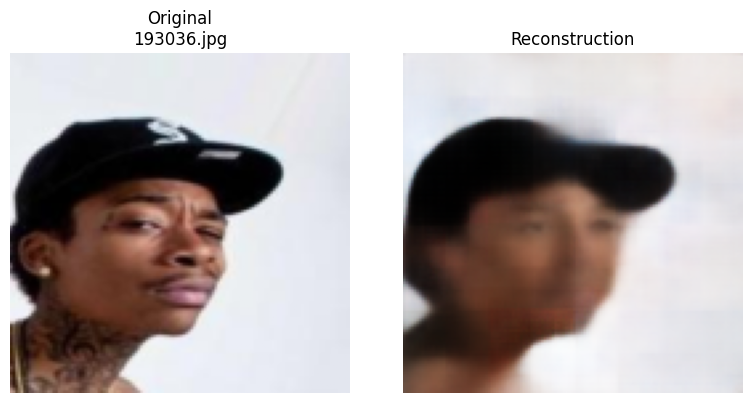

In [14]:
# Show one reconstruction example
image_files = sorted([p for p in LOCAL_IMG_ROOT.iterdir() if p.suffix.lower() == ".jpg"])
if len(image_files) == 0:
    raise RuntimeError(f"No JPG images found in {LOCAL_IMG_ROOT}")

test_path = random.choice(image_files)
print("Using test image:", test_path.name)

img_tensor, pil_img = load_face_tensor(test_path)

with torch.no_grad():
    mu, _ = model.encoder(img_tensor)
    recon = model.decoder(mu)

orig = tensor_to_image(img_tensor)
reconstructed = tensor_to_image(recon)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(orig)
plt.title(f"Original\n{test_path.name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed)
plt.title("Reconstruction")
plt.axis("off")

plt.tight_layout()
plt.show()

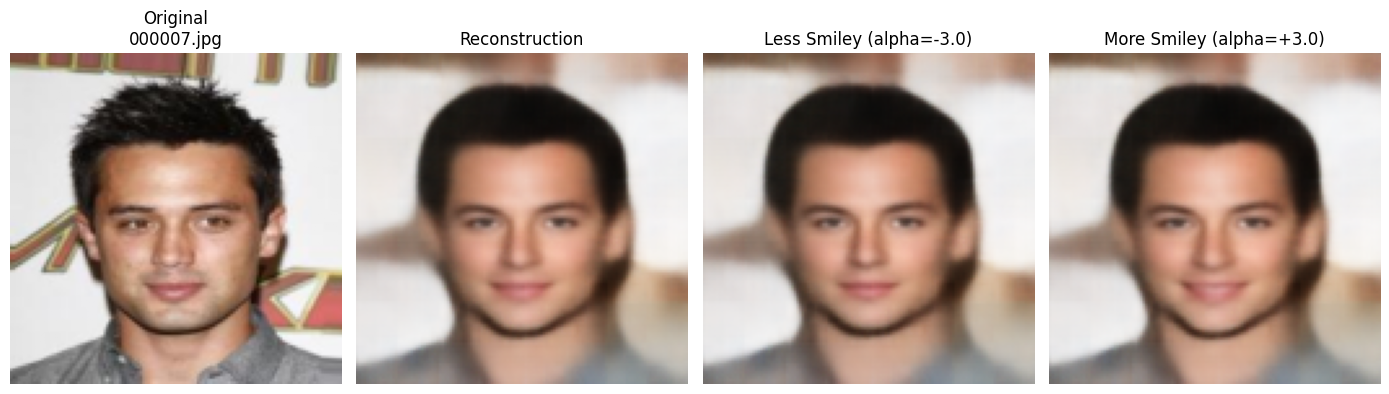

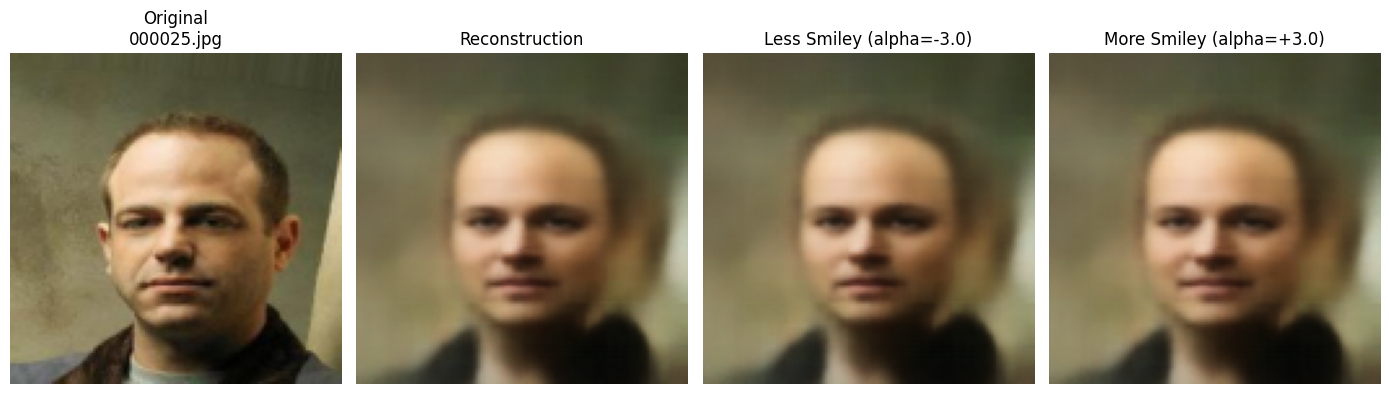

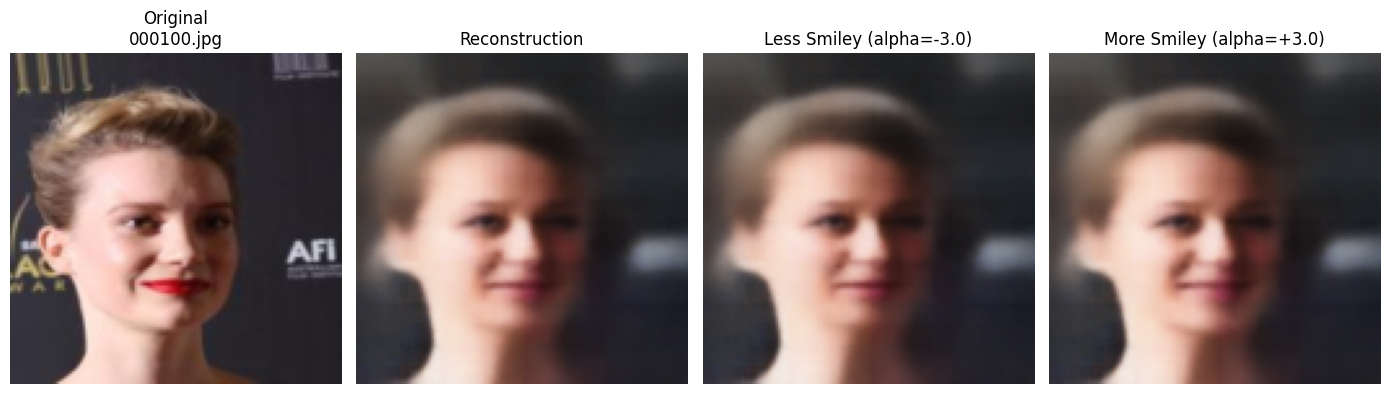

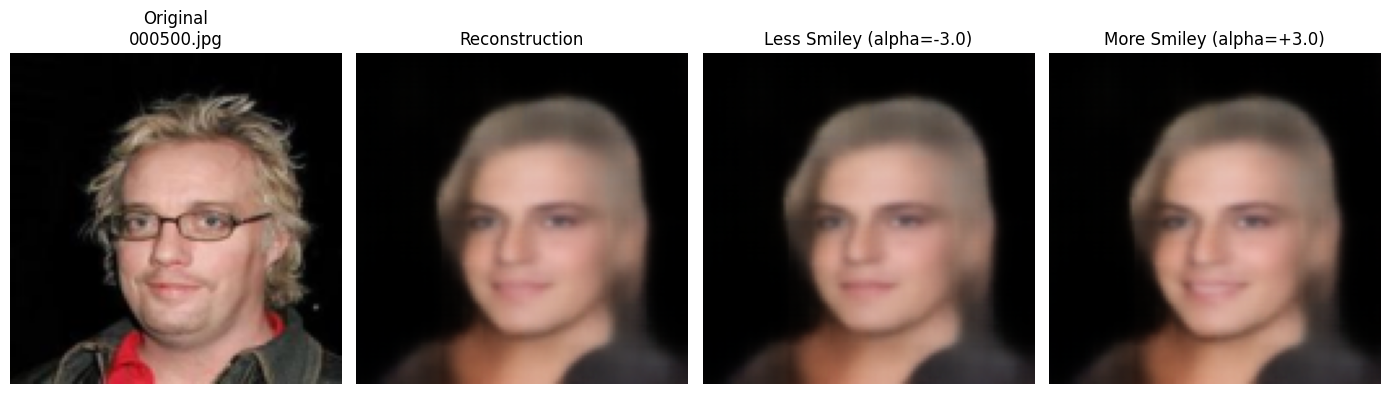

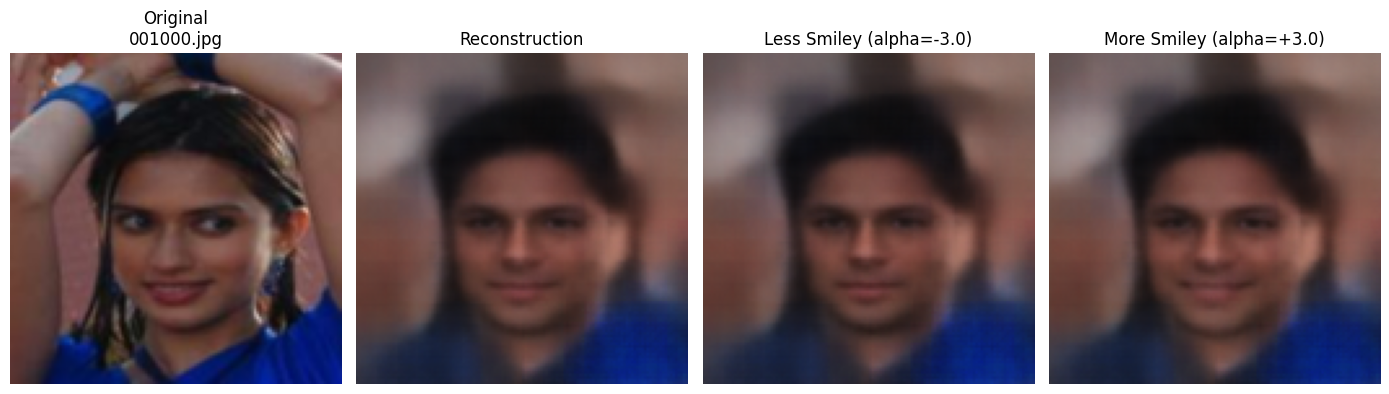

Saved outputs to /content/drive/MyDrive/CIS433_Hadi Hussain__Project2_Smiley/hadi_outputs


In [15]:
# Generate more smiley and less smiley results for five test images
chosen_ids = ["000007.jpg", "000025.jpg", "000100.jpg", "000500.jpg", "001000.jpg"]

alpha = 3.0
OUTPUT_DIR = PROJECT_DIR / "hadi_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for img_name in chosen_ids:
    test_path = LOCAL_IMG_ROOT / img_name
    img_tensor, pil_img = load_face_tensor(test_path)

    with torch.no_grad():
        mu, _ = model.encoder(img_tensor)

        z_less = mu - alpha * attribute_vec.unsqueeze(0)
        z_more = mu + alpha * attribute_vec.unsqueeze(0)

        img_recon = model.decoder(mu)
        img_less = model.decoder(z_less)
        img_more = model.decoder(z_more)

    orig = tensor_to_image(img_tensor)
    recon = tensor_to_image(img_recon)
    less_smiley = tensor_to_image(img_less)
    more_smiley = tensor_to_image(img_more)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(orig)
    plt.title(f"Original\n{img_name}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(recon)
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(less_smiley)
    plt.title(f"Less Smiley (alpha=-{alpha})")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(more_smiley)
    plt.title(f"More Smiley (alpha=+{alpha})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Save outputs
    base = img_name.replace(".jpg", "")
    Image.fromarray((np.clip(less_smiley, 0, 1) * 255).astype(np.uint8)).save(OUTPUT_DIR / f"{base}_less_smiley.png")
    Image.fromarray((np.clip(more_smiley, 0, 1) * 255).astype(np.uint8)).save(OUTPUT_DIR / f"{base}_more_smiley.png")

print(f"Saved outputs to {OUTPUT_DIR}")

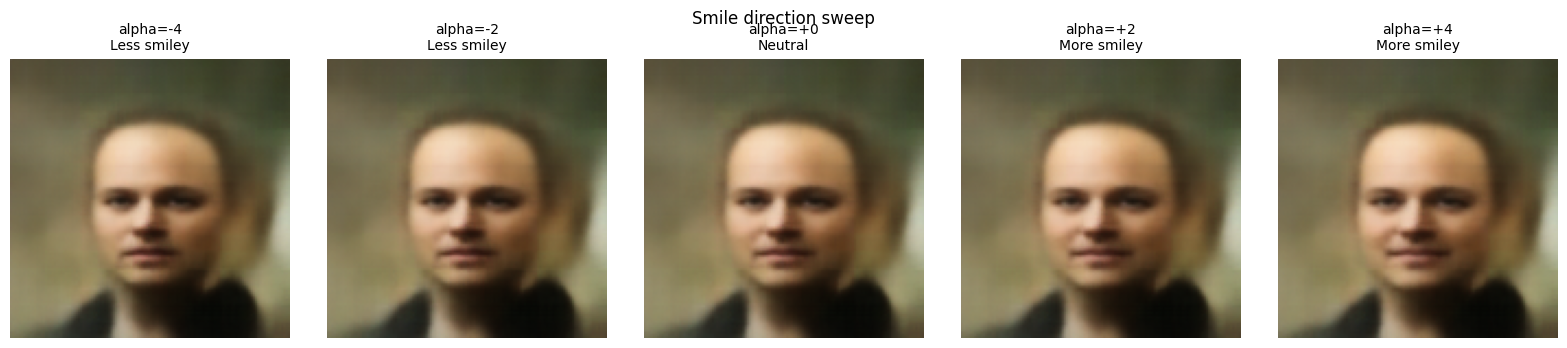

In [16]:
# Alpha sweep to show continuous effect of edit strength
alpha_values = [-4, -2, 0, 2, 4]
sweep_path = LOCAL_IMG_ROOT / "000025.jpg"

sweep_tensor, _ = load_face_tensor(sweep_path)

with torch.no_grad():
    mu, _ = model.encoder(sweep_tensor)

fig, axes = plt.subplots(1, len(alpha_values), figsize=(16, 3.5))
for ax, a in zip(axes, alpha_values):
    with torch.no_grad():
        z_edit = mu + a * attribute_vec.unsqueeze(0)
        edited = model.decoder(z_edit)
    ax.imshow(tensor_to_image(edited))
    label = "Neutral" if a == 0 else ("Less smiley" if a < 0 else "More smiley")
    ax.set_title(f"alpha={a:+d}\n{label}", fontsize=10)
    ax.axis("off")

plt.suptitle("Smile direction sweep", fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
OUTPUT_MODEL_PATH = PROJECT_DIR / "hadi_project2_model_submission.pt"
torch.save(model.state_dict(), OUTPUT_MODEL_PATH)
print("Saved model to:", OUTPUT_MODEL_PATH)

# Verify reload works
reload_model = VAE().to(device)
reload_model.load_state_dict(torch.load(OUTPUT_MODEL_PATH, map_location=device))
reload_model.eval()
print("Reload verification passed.")

Saved model to: /content/drive/MyDrive/CIS433_Hadi Hussain__Project2_Smiley/hadi_project2_model_submission.pt
Reload verification passed.
